# Mini Project 3

*Date:* 26/04/2026

*Name:* Mikkel Korsgaard Sørensen

*Institution:* ES AAU

*Class:* NDS8

*Subject:* Numerical Scientific Computing

*Github Repo* https://github.com/NDS8-TCP/nsc-mikkel

*System specifications:*

- *CPU:* AMD Ryzen 7 PRO 6850U (16) @ 4.77 GHz

- *GPU:* AMD Radeon 680M [Integrated]

- *RAM:* 32 GiB LPDDR5 @ 6400 MT/s

- *OS*: Debian GNU/Linux forky/sid (forky) x86_64

## Lecture 8: Computer Arithmetic & Numerical Accuracy

### ****Milestone 1:** Mandelbrot Trajectory Divergence**

****Goal:** find where float32 and float64 Mandelbrot trajectories diverge, and map the divergence iteration over the grid.**

****Region (default):** Seahorse Valley — $x \in [−0.7530, −0.7490]$, $y \in [0.0990, 0.1030]$, `max_iter = 1000`**

In [1]:
# From slide 38
# Updated by me for the exercise questions

import numpy as np
import matplotlib.pyplot as plt

def mandelbrot_trajectory_divergence(
    x_min = -0.7530,
    x_max = -0.7490,
    y_min = 0.0990,
    y_max = 0.1030,
    N =  512,
    MAX_ITER = 1000,
    TAU = 0.01
):
    """Compute the mandel set in the famous trajectory region,
    Keeping track of which points diverged based on threshold.
    
    Parameters
    ----------
    x_min : float, optional
        Minimum x-value (left boundary) of the complex plane.
    x_max : float, optional
        Maximum x-value (right boundary) of the complex plane.
    y_min : float, optional
        Minimum y-value (bottom boundary) of the complex plane.
    y_max : float, optional
        Maximum y-value (top boundary) of the complex plane.
    N : int, optional
        The pixel width and height.
    MAX_ITER : int, optional
        Maximum number of iterations per pixel.
    TAU : float, optional
        The threshold on wish to include pixels or not.

    Returns
    -------
    diverge
        A numpy matrix (height x width) with diverged pixels.
    active
        A numpy matrix (height x width) with active pixels.
    """

    # Image grid
    x = np.linspace(x_min, x_max, N)
    y = np.linspace(y_min, y_max, N)

    # Grid of complex numbers (numpy style) float32 and float64
    C64 = (x[np.newaxis, :] + 1j * y[:, np.newaxis]).astype(np.complex128)
    C32 = C64.astype(np.complex64)

    # Mandelbrot computed results saved to for each iteration
    z32 = np.zeros_like(C32)
    z64 = np.zeros_like(C64)

    # Grid of iterations reach
    diverge = np.full((N, N), MAX_ITER, dtype=np.int32)

    # If to include a pixel when compute mandelbrot
    active = np.ones((N, N), dtype=bool)

    for k in range(MAX_ITER):
        
        # Early exit
        if not active.any():
            break

        # Compute mandelbrot
        z32[active] = z32[active]**2 + C32[active]
        z64[active] = z64[active]**2 + C64[active]

        # Note the differences between float32 and float64 
        diff = (np.abs(z32.real.astype(np.float64) - z64.real)
                + np.abs(z32.imag.astype(np.float64) - z64.imag))
        
        # For the alive pixels, did any of them exceed the threshold?
        newly = active & (diff > TAU)

        # If so, note down the iteration count and kill the pixel
        diverge[newly] = k
        active[newly] = False
    
    return diverge, active

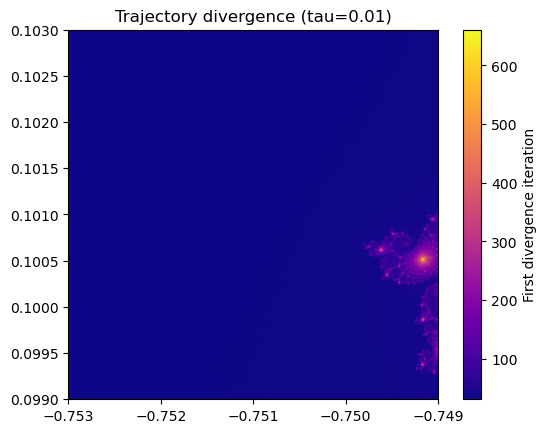

In [2]:
# Plot
tau=0.01
n=512
max_iter = 1000
diverge, active = mandelbrot_trajectory_divergence(N=n,MAX_ITER=max_iter,TAU=tau)
plt.imshow(diverge, cmap='plasma', origin='lower',
           extent=[-0.7530, -0.7490, 0.0990, 0.1030])
plt.colorbar(label='First divergence iteration')
plt.title(f'Trajectory divergence (tau={tau})')
plt.show()

Note from Jimmy: Complex number has both real and imaginary parts. So for `complex128` each part gets 64 bits etc.

****Algorithm:****
1. **Build two coordinate arrays: `C32 = C.astype(np.complex64)` and `C64`**
2. **Iterate $z_{n+1} = z^n_2 + c$ simultaneously for both dtypes, step by step**
3. **Record the first iteration $k$ where $|z_{32}^{(k)} − z_{64}^{(k)} | > \tau $ (try $\tau = 0.01$)**
4. **Map these divergence iterations over the grid with `plt.imshow`**

****Observations to make:****

- **What fraction of pixels diverge before `max_iter`?**

In [3]:
pixels_total = diverge.size
pixels_diverged = np.sum(diverge < max_iter)

print(f"Out of {pixels_total:d} pixels, {pixels_diverged:d} pixels diverged")
print(f"A fraction of: {(pixels_diverged/pixels_total)*100:.2f}%")

Out of 262144 pixels, 262144 pixels diverged
A fraction of: 100.00%


- **Where do trajectories diverge *early*? Compare visually to the escape-count map.**

"escape-count map" is just the normal mandelbrot algorithm. 

*Note:* that I am using my numpy implementation to compare against.

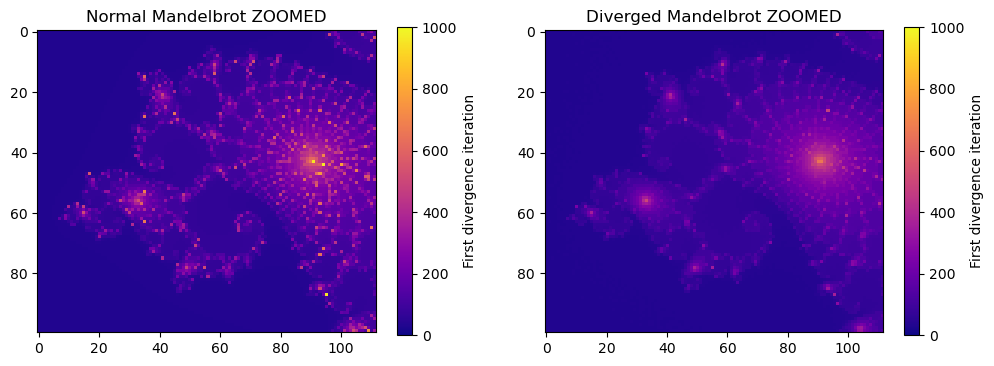

In [4]:
from mandelbrot import compute_mandelbrot_numpy

tau=0.01
n=512
max_iter = 1000
x_min = -0.7530
x_max = -0.7490
y_min = 0.0990
y_max = 0.1030

normal_image = compute_mandelbrot_numpy(x_min, x_max, y_min, y_max, n, n, max_iter)
diverged_image, _ = mandelbrot_trajectory_divergence(x_min, x_max, y_min, y_max, n, max_iter, tau)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Iterations
im1 = axes[0].imshow(normal_image[150:250, 400:], cmap='plasma', vmin=0, vmax=max_iter)
axes[0].set_title("Normal Mandelbrot ZOOMED")
plt.colorbar(im1, label='First divergence iteration')

# Diverges
im2 = axes[1].imshow(diverged_image[150:250, 400:], cmap='plasma', vmin=0, vmax=max_iter)
axes[1].set_title("Diverged Mandelbrot ZOOMED")
plt.colorbar(im2, label='First divergence iteration')

plt.show()

Pixels diverge early in the purple and later in the yellow. From the images it appears that both diverges late in the complex contours of the mandelbrot shape, except that the diverged function on the left, reaches it quicker.

- **Does early divergence correlate with high escape iteration counts?**

Yes it does. By looking at the figures above, diverges does correlate to iteration counts.

****Done?** Record region, $\tau$ , and a brief observation in your performance notebook (MP3) → commit.**

```sh
┌──(mikkel@pella)-[~/Sync/AAU/Semester 8/github/nsc-mikkel]
└─$ git log -n 1
commit 0cc8b727791394bda019c8f8bf4d7ea084edee76 (HEAD -> main)
Author: mikkel-coder <mikkel.ks.sorensen@gmail.com>
Date:   Sun Apr 12 12:07:40 2026 +0000

    l08: milestone 1 done
```

### ****Milestone 2:** Mandelbrot Sensitivity Map**

****Goal:** compute a per-pixel condition number approximation for $f(c) = n_{escape}(c)$.**

From theory: $\kappa(f, c) =  |\frac{c f´(c)}{f(c)}|$. Substituting $f′(c) \approx \Delta n/\delta$ and $\delta = \varepsilon_{32} \cdot |c|$:

$$
\kappa(c) \approx \frac{|\Delta n|}{\varepsilon_{32} \cdot n(c)}, 
\space 
\Delta n = n(c + \delta) − n(c)
$$

****Region:** same as M1 (Seahorse Valley, `max_iter = 1000`)**

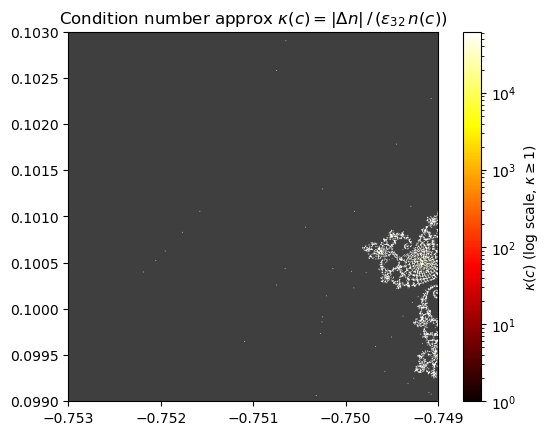

In [5]:
# From slide 40
# Format and comments made by me

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Parameter
N, MAX_ITER = 512, 1000

# image grid
x = np.linspace(-0.7530, -0.7490, N)
y = np.linspace(0.0990, 0.1030, N)

# grid of complex numbers - used to compute mandelbrot
C = (x[np.newaxis, :] + 1j * y[:, np.newaxis]).astype(np.complex128)

# Machine precision
eps32 = float(np.finfo(np.float32).eps)
delta = np.maximum(eps32 * np.abs(C), 1e-10)


def escape_count(C, max_iter):
    z = np.zeros_like(C)
    iterations = np.full(C.shape, max_iter, dtype=np.int32)
    escaped = np.zeros(C.shape, dtype=bool)
    for k in range(max_iter):
        z[~escaped] = z[~escaped]**2 + C[~escaped]
        newly = ~escaped & (np.abs(z) > 2.0)
        iterations[newly] = k
        escaped[newly] = True
    return iterations


n_base = escape_count(C,         MAX_ITER).astype(float)
n_perturb = escape_count(C + delta, MAX_ITER).astype(float)
dn = np.abs(n_base - n_perturb)
kappa = np.where(n_base > 0, dn / (eps32 * n_base), np.nan)

# plot
cmap_k = plt.cm.hot.copy()
cmap_k.set_bad('0.25')
vmax = np.nanpercentile(kappa, 99)
plt.imshow(kappa, cmap=cmap_k, origin='lower',
           extent=[-0.7530, -0.7490, 0.0990, 0.1030],
           norm=LogNorm(vmin=1, vmax=vmax))
plt.colorbar(label=r'$\kappa(c)$ (log scale, $\kappa \geq 1$)')
plt.title(
    r'Condition number approx $\kappa(c) = |\Delta n|\,/\,(\varepsilon_{32}\,n(c))$')
plt.show()

****Algorithm:****
1. **Compute $n(c)$ and $n(c + \delta)$; $\delta = \varepsilon_{32} \cdot |c|$**
2. **$\kappa(c) = |\Delta n| / (\varepsilon_{32} \cdot n(c))$; use `np.nan` where $n(c) = 0$**
3. **Plot with `cmap='hot'` and `LogNorm` ($\kappa$ spans many orders of magnitude; linear scale → black image). Use `vmin=1` ($\kappa < 1$ is well-conditioned). Set `cmap.set_bad('0.25')` so NaN pixels (grey) are not confused with high-$\kappa$ pixels (white).**

****Observations:****

- **Where is $\kappa$ largest? Does it match the boundary in M1?**

The image above shows the difference in sensitivity compared to normal mandelbrot and mandelbrot with machine precision included. The grey areas highlight no that there is no difference. $\kappa$ appears to be large at the complex curvatures of the mandelbrot set which does match my image from milestone 1.

- **What is $\kappa$ for interior pixels (`n = max_iter`)?**

The interior pixels where `n = max_iter` $\kappa \approx 0$. The reason is because both the original point and the perturbed point remains in bounds thus they do no escape. For example `n_base = n_perturb = 1000` thus `dn = 0`

$$
\kappa = \frac{\text{dn}}{(\text{eps32} \cdot \text{n\_base})} = 0
$$

****Done?** Add a brief note comparing M1 and M2 maps to your performance notebook (MP3) → commit.**

```sh
┌──(mikkel@pella)-[~/Sync/AAU/Semester 8/github/nsc-mikkel]
└─$ git log -n 1
commit f9939feee60e84fd05fd280636f418acafea17a1 (HEAD -> main)
Author: mikkel-coder <mikkel.ks.sorensen@gmail.com>
Date:   Sun Apr 12 12:50:50 2026 +0000

    l08: milestone 2 done
```

## Lecture 9: Testing & Documentation

### ****Milestone 1:** Test Suite**

****Goal:** create `test_mandelbrot.py` with a meaningful test suite. **Requirements:****

- **$\ge 3$ individual test functions on core computation functions (not on timing, plotting, or I/O)**

I have chosen the function from slide 20.

- **At least one test using `@pytest.mark.parametrize` — across multiple inputs *or* across multiple implementations**

- **Assertions must verify *correctness*, not just “runs without crashing”**

Noted!

In [1]:
%pycat test_mandelbrot.py

from multiprocessing import Pool
import pytest
import numpy as np
from numba import njit

## Function to test
def mandelbrot_pixel(c: complex, max_iter: int) -> int:
    # From slide 20
    z = 0j
    for n in range(max_iter):
        if z.real*z.real + z.imag*z.imag > 4.0:
            return n
        z = z*z + c
    return max_iter

## >= 3 test functions
# Cases based on the ones from lecture 9 code_examples.md
def test_origin():
    assert mandelbrot_pixel(0+0j, 100) == 100

def test_far_outside():
    # escapes on iteration 1
    assert mandelbrot_pixel(5.0+0j, 100) == 1

def test_left_tip():
    assert mandelbrot_pixel(-2.5+0j, 100) == 1

## Using pytest.mark.parametrize (across multiple inputs)
KNOWN_CASES = [
    (0+0j,    100, 100),   # origin: never escapes
    (5.0+0j,  100,   1),   # far outside, escapes on iteration 1
    (-2.5+0j, 100,   1),   # left tip of set
]

@pytest.mark.parametrize("c, max_iter, expected", KNOWN_CASES)
def test_pixel_all(c, max_iter, expected):
   

**What are trustworthy test values?**

- ****Analytically provable** — derived from the definition, no implementation needed. Choose points whose behaviour you can prove from the mathematics alone and state why.**

**$z_0 = 0+0i$**

$$z_1 = (0^2) + (0^2) = 0 + 0i$$

Then ->:

$z_{n+1} = 0+0i$

Thus it never escapes.

**$z_0 = 5+0i$**

$$z_1 = (5^2) + (0^2) = 25 + 0i$$

Thus: it will escape at the first iteration.

**$z_0 = -2.5 + 0i$**

$$z_1 = (-2.5^2)+(0^2) = 25 + 0i$$

Thus: it also will escape at the first iteration.

- ****Cross-validation** — naive loop as oracle; test that NumPy/Numba/multiprocessing agree on a small grid (32×32)**

Done. Please see the code above.

- ****Float32 note** — cross-validate float32 implementations against each other, not against float64 (boundary pixels will differ)**

Noted! I am not mixing any float32 and float64 implementations

**Run and record:**

1. `pytest -v` — note pass count

In [2]:
!pytest -v

============================= test session starts ==============================
platform linux -- Python 3.11.14, pytest-9.0.2, pluggy-1.6.0 -- /opt/conda/envs/nsc/bin/python3.11
cachedir: .pytest_cache
hypothesis profile 'default'
rootdir: /ncs
plugins: cov-7.1.0, hypothesis-6.152.1
collected 12 items                                                             

l09_ex1_test.py::test_ex1_step1 PASSED                                   [  8%]
l09_ex1_test.py::test_ex1_step2 PASSED                                   [ 16%]
test_mandelbrot.py::test_origin PASSED                                   [ 25%]
test_mandelbrot.py::test_far_outside PASSED                              [ 33%]
test_mandelbrot.py::test_left_tip PASSED                                 [ 41%]
test_mandelbrot.py::test_pixel_all[0j-100-100] PASSED                    [ 50%]
test_mandelbrot.py::test_pixel_all[(5+0j)-100-1] PASSED                  [ 58%]
test_mandelbrot.py::test_pixel_all[(-2.5+0j)-100-1] PASSED               

The pass count is 12.

2. `pytest --cov=. -v` — note coverage %

In [3]:
!pytest --cov=. -v

============================= test session starts ==============================
platform linux -- Python 3.11.14, pytest-9.0.2, pluggy-1.6.0 -- /opt/conda/envs/nsc/bin/python3.11
cachedir: .pytest_cache
hypothesis profile 'default'
rootdir: /ncs
plugins: cov-7.1.0, hypothesis-6.152.1
collected 12 items                                                             

l09_ex1_test.py::test_ex1_step1 PASSED                                   [  8%]
l09_ex1_test.py::test_ex1_step2 PASSED                                   [ 16%]
test_mandelbrot.py::test_origin PASSED                                   [ 25%]
test_mandelbrot.py::test_far_outside PASSED                              [ 33%]
test_mandelbrot.py::test_left_tip PASSED                                 [ 41%]
test_mandelbrot.py::test_pixel_all[0j-100-100] PASSED                    [ 50%]
test_mandelbrot.py::test_pixel_all[(5+0j)-100-1] PASSED                  [ 58%]
test_mandelbrot.py::test_pixel_all[(-2.5+0j)-100-1] PASSED               

In our file of interest `test_mandelbrot.py` it is 69% coverage.

****Done?** Record pass count and coverage % in your performance notebook (MP3) → commit.**

```sh
mikkel@samos:~/Sync/AAU/Semester 8/github/nsc-mikkel$ git log -n 1
commit dc8ce60c2cb9b92be67cba7d585d1c4ae059026b (HEAD -> main)
Author: mikkel-coder <mikkel.ks.sorensen@gmail.com>
Date:   Sun Apr 19 13:07:30 2026 +0000

    l09: milestone 1 done
```

### ****Milestone 2:** Docstrings and Type Hints**

```python
def mandelbrot_pixel(c: complex, max_iter: int) -> int:
    """Compute the escape iteration count for one complex point.

    Iterates z_{n+1} = z_n^2 + c from z_0 = 0 until
    |z| > 2 (escape) or reaching max_iter.

    Parameters
    ----------
    c : complex
        Complex coordinate to test for set membership.
    max_iter : int
        Maximum iterations; returned if trajectory does not escape.

    Returns
    -------
    int
        First iteration k where |z_k| > 2, or max_iter.
    """
    ...
```

****Goal:** fully document one version of your Mandelbrot code — docstrings and type hints on every public function; verify with `ruff check`.**

#### ****Step 1:** — pick one implementation and add to every public function:**

I have chosen the same function from l09 exercises

In [4]:
%pycat your_mandelbrot.py

import numpy as np
import numpy.typing as npt
from mandelbrot_pixel import mandelbrot_pixel

@njit
def mandelbrot_chunk(
    row_start: int, 
    row_end: int, 
    N: int,
    x_min: float, 
    x_max: float, 
    y_min: float, 
    y_max: float, 
    max_iter: int
) -> npt.NDArray[np.int32]:
    """Computes the mandelbrot set based on a single chunk.
    
    Parameters
    ----------
    row_start : int
        The starting index at which the chunk begins.
    row_end : int
        The end index at which the chunk ends.
    N : int
        Number of columns (image width). Assumes squared result image.
    x_min : float
        Minimum x-value (left boundary) of the complex plain.
    x_max : float
        Maximum x-value (right boundary) of the complex plain.
    y_min : float
        Minimum y-value (bottom boundary) of the complex plain.
    y_max : float
        Maximum y-value (top boundary) of the complex plain.
    max_iter : int
        Maximum number of iterations per pixel.

- **A docstring in NumPy style (one-line summary + Parameters + Returns)**

Done. Please see the code.

- **Type hints on all parameters and return values**

Done. Please see the code.

#### ****Step 2:** — run ruff:**

```sh
mamba install ruff
ruff check your_mandelbrot.py # fix all reported issues before committing
```

I get the following outputs:

In [5]:
!ruff check your_mandelbrot.py

All checks passed!


**Type hints also power Pylance:**

- **In VSCode: Settings → Settings → search “type checking mode” → set to `basic`**

I am using VSCode.

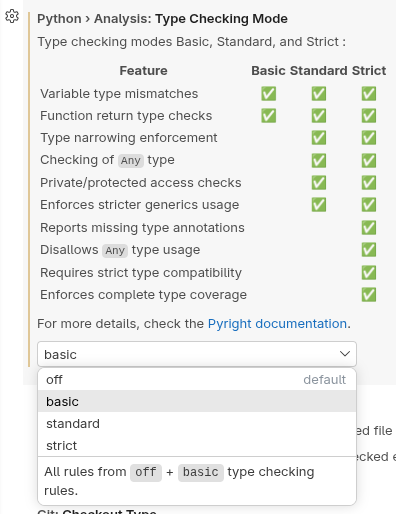

- **Pylance uses your annotations to flag type mismatches in real time (Problems tab)**

I am not using pylance.

****Done?** `ruff check` reports 0 errors → commit.**

In [6]:
!ruff check your_mandelbrot.py

All checks passed!


## Lecture 10: GPU Computing - Introduction

### ****Milestone 1:** Mandelbrot Float32 Kernel (35 min)**

****Follow** `mandelbrot_tutorial.md` (attached on Moodle). Type the code yourself — that is the goal. The tutorial walks through every step. If you get stuck, peek at `mandelbrot_opencl.py` (don’t open until your own version runs).**

#### ****Step 0** — Prerequisites**

- **PyOpenCL installed and working (you verified this at the end of L09):**

In [1]:
!python -c "import pyopencl as cl; [print(p.name, [d.name for d in p.get_devices()]) for p in cl.get_platforms()]"

AMD Accelerated Parallel Processing ['gfx1035']
Intel(R) OpenCL ['AMD Ryzen 7 PRO 6850U with Radeon Graphics     ']


**should list your GPU — not just Portable Computing Language ['cpu']**

It does list my GPU **✓**

- **Your Numba Mandelbrot from MP1 in front of you. You will port its inner loop to OpenCL C.**

Noted!

**Create a new file `mandelbrot_gpu.py` in your MP3 repo and follow along.**

In [2]:
!touch mandelbrot_gpu.py

#### **Step 1 — The host/device mental model**

**A PyOpenCL program has two halves:**

| Half   | Lives in    | Written in | Role                                              |
| ------ | ----------- | ---------- | ------------------------------------------------- |
| Host   | Your Python | Python     | Allocate buffers, launch kernels, collect results |
| Device | The GPU     | OpenCL C   | The kernel — the parallel loop body               |

**Three objects connect them:**

- **Context (`cl.Context`) — "who am I talking to?" — one or more devices.**

- **Command queue (`cl.CommandQueue`) — an ordered pipe for work sent to a device.**

- **Buffer (`cl.Buffer`) — a region of device memory. Inputs and outputs live here.**

**The pattern is always: *create context + queue → allocate buffers → compile kernel → enqueue kernel → copy results back*.**

I shall note all of this! In step 2, we do this "plumbing".

#### ****Step 2 — Skeleton:** the shortest possible program that launches a kernel**

**Type this in. It does nothing useful yet, but it verifies the plumbing.**

In [3]:
%pycat mandelbrot_gpu.py

import pyopencl as cl
import numpy as np

KERNEL_SRC = """
__kernel void hello(__global int *out) {
    int i = get_global_id(0);
    out[i] = i * i;
}
"""

ctx   = cl.create_some_context(interactive=False)
queue = cl.CommandQueue(ctx)
prog  = cl.Program(ctx, KERNEL_SRC).build()

N = 8
out = np.zeros(N, dtype=np.int32)
out_dev = cl.Buffer(ctx, cl.mem_flags.WRITE_ONLY, out.nbytes)

prog.hello(queue, (N,), None, out_dev)
cl.enqueue_copy(queue, out, out_dev)
queue.finish()

print(out)     # → [ 0  1  4  9 16 25 36 49]


**Run it. If this prints the squares, your whole toolchain works. If it fails, fix that now — every later step builds on it.**

In [4]:
%run mandelbrot_gpu.py

/opt/conda/envs/nsc/lib/python3.11/site-packages/pyopencl/__init__.py:578: UserWarning: PyOpenCL compiler caching failed with an exception:
[begin exception]
Traceback (most recent call last):
  File "/opt/conda/envs/nsc/lib/python3.11/site-packages/pyopencl/cache.py", line 514, in create_built_program_from_source_cached
    _create_built_program_from_source_cached(
  File "/opt/conda/envs/nsc/lib/python3.11/site-packages/pyopencl/cache.py", line 424, in _create_built_program_from_source_cached
    src = src + b"\n\n__constant int pyopencl_defeat_cache_%s = 0;" % (
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: %b requires a bytes-like object, or an object that implements __bytes__, not 'str'
[end exception]
  lambda: create_built_program_from_source_cached(


[ 0  1  4  9 16 25 36 49]


It works! (ignore warnings)

#### ****Step 3** — Kernel signature for Mandelbrot**

**Decide what the kernel needs to know. For each pixel you need:**

- **Pixel coordinates (row, col) — the kernel gets these from `get_global_id`**
- **The view window (`x_min, x_max, y_min, y_max`)**
- **Image dimension `N`**
- **`max_iter`**
- **Somewhere to write the result**

**So the signature is:**

```c
__kernel void mandelbrot(
    __global int *result,
    const float x_min, const float x_max,
    const float y_min, const float y_max,
    const int N, const int max_iter)
{
    // body to fill in
}
```

**Add this to your Python file as the new `KERNEL_SRC`. Leave the body empty for now. Note: one work-item = one pixel. We'll launch with an NDRange of `(N, N)`, so `get_global_id(0)` gives the column and `get_global_id(1)` the row.**

In [5]:
%pycat mandelbrot_gpu.py

import pyopencl as cl
import numpy as np

KERNEL_SRC = """
__kernel void mandelbrot(
    __global int *result,
    const float x_min, const float x_max,
    const float y_min, const float y_max,
    const int N, const int max_iter)
{
    // body to fill in
}
"""

ctx   = cl.create_some_context(interactive=False)
queue = cl.CommandQueue(ctx)
prog  = cl.Program(ctx, KERNEL_SRC).build()

N = 8
out = np.zeros(N, dtype=np.int32)
out_dev = cl.Buffer(ctx, cl.mem_flags.WRITE_ONLY, out.nbytes)

prog.hello(queue, (N,), None, out_dev)
cl.enqueue_copy(queue, out, out_dev)
queue.finish()

print(out)     # → [ 0  1  4  9 16 25 36 49]


I have added it. I have noted the text.

#### ****Step 4** — Map pixel → complex number**

**At the top of the body:**

```c
int col = get_global_id(0);
int row = get_global_id(1);
if (col >= N || row >= N) return;   // guard against over-launch

float c_real = x_min + col * (x_max - x_min) / (float)N;
float c_imag = y_min + row * (y_max - y_min) / (float)N;
```

**Two things to notice:**

- ****Explicit cast** `(float)N`. Integer division is a classic C bug. If you forget the cast, you get 0.0 for most pixels. (See Appendix A.)**
- ****No NumPy.** The kernel is scalar code. One work-item = one pixel = one Python loop iteration you did in MP1.**


I have noticed this!

#### ****Step 5** — Translate the escape-time loop**

**Your Numba inner loop probably looks like this:**

```python
zr, zi = 0.0, 0.0
count = 0
while count < max_iter and zr*zr + zi*zi <= 4.0:
    zr, zi = zr*zr - zi*zi + c_real, 2.0 * zr * zi + c_imag
    count += 1
```

**The OpenCL C version is line-for-line analogous, except Python's simultaneous assignment does not exist — you need a temp:**

```c
float zr = 0.0f, zi = 0.0f;
int count = 0;
while (count < max_iter && zr*zr + zi*zi <= 4.0f) {
    float tmp = zr*zr - zi*zi + c_real;
    zi = 2.0f * zr * zi + c_imag;
    zr = tmp;
    count++;
}
result[row * N + col] = count;
```

**The `f` suffix (`0.0f, 4.0f, 2.0f`) keeps literals as `float`. Without it, `4.0` is a `double`, which silently promotes the whole expression and slows the kernel on GPUs where double is expensive.**

**Your kernel is now complete. Copy its source into the `KERNEL_SRC` triple-quoted string.**

Yes. We do indeed need a tmp variable. I shall copy it.

In [6]:
%pycat mandelbrot_gpu.py

import pyopencl as cl
import numpy as np

KERNEL_SRC = """
__kernel void mandelbrot(
    __global int *result,
    const float x_min, const float x_max,
    const float y_min, const float y_max,
    const int N, const int max_iter)
{
    int col = get_global_id(0);
    int row = get_global_id(1);
    if (col >= N || row >= N) return;   // guard against over-launch

    float c_real = x_min + col * (x_max - x_min) / (float)N;
    float c_imag = y_min + row * (y_max - y_min) / (float)N;

    float zr = 0.0f, zi = 0.0f;
    int count = 0;
    while (count < max_iter && zr*zr + zi*zi <= 4.0f) {
        float tmp = zr*zr - zi*zi + c_real;
        zi = 2.0f * zr * zi + c_imag;
        zr = tmp;
        count++;
    }
    result[row * N + col] = count;
}
"""

ctx   = cl.create_some_context(interactive=False)
queue = cl.CommandQueue(ctx)
prog  = cl.Program(ctx, KERNEL_SRC).build()

N = 8
out = np.zeros(N, dtype=np.int32)
out_dev = cl.Buffer(ctx, cl.mem_flags.WRITE_ONLY, out.nbytes)

prog.hello

#### ****Step 6** — Host code: buffers, launch, copy back**

**Below the `ctx/queue/prog` setup, add:**

```c
N, MAX_ITER = 1024, 200
X_MIN, X_MAX = -2.5, 1.0
Y_MIN, Y_MAX = -1.25, 1.25

image = np.zeros((N, N), dtype=np.int32)
image_dev = cl.Buffer(ctx, cl.mem_flags.WRITE_ONLY, image.nbytes)

prog.mandelbrot(
    queue, (N, N), None,      # global size (N, N); let OpenCL pick local
    image_dev,
    np.float32(X_MIN), np.float32(X_MAX),
    np.float32(Y_MIN), np.float32(Y_MAX),
    np.int32(N), np.int32(MAX_ITER),
)

cl.enqueue_copy(queue, image, image_dev)
queue.finish()
```

**Two details that matter:**

- ****Every scalar must be wrapped as `np.float32(...)` or `np.int32(...)`.** PyOpenCL won't convert Python scalars for you — a plain `1024` vs `np.int32(1024)` mismatches the kernel signature and fails silently with garbled output.**
- **`queue.finish()` is the barrier. Without it, the copy may not have completed when Python reads `image`.**

I have added it. I have noted the text above!

In [7]:
%pycat mandelbrot_gpu.py

import pyopencl as cl
import numpy as np

KERNEL_SRC = """
__kernel void mandelbrot(
    __global int *result,
    const float x_min, const float x_max,
    const float y_min, const float y_max,
    const int N, const int max_iter)
{
    int col = get_global_id(0);
    int row = get_global_id(1);
    if (col >= N || row >= N) return;   // guard against over-launch

    float c_real = x_min + col * (x_max - x_min) / (float)N;
    float c_imag = y_min + row * (y_max - y_min) / (float)N;

    float zr = 0.0f, zi = 0.0f;
    int count = 0;
    while (count < max_iter && zr*zr + zi*zi <= 4.0f) {
        float tmp = zr*zr - zi*zi + c_real;
        zi = 2.0f * zr * zi + c_imag;
        zr = tmp;
        count++;
    }
    result[row * N + col] = count;
}
"""

ctx   = cl.create_some_context(interactive=False)
queue = cl.CommandQueue(ctx)
prog  = cl.Program(ctx, KERNEL_SRC).build()

N, MAX_ITER = 1024, 200
X_MIN, X_MAX = -2.5, 1.0
Y_MIN, Y_MAX = -1.25, 1.25

image = np.zeros((N, N), dtype=np.in

#### ****Step 7** — Time it and save the image**

```python
import time, matplotlib.pyplot as plt

# --- Warm up (first launch triggers a kernel compile) ---
prog.mandelbrot(queue, (64, 64), None, image_dev,
                np.float32(X_MIN), np.float32(X_MAX),
                np.float32(Y_MIN), np.float32(Y_MAX),
                np.int32(64), np.int32(MAX_ITER))
queue.finish()

# --- Time the real run ---
t0 = time.perf_counter()
prog.mandelbrot(queue, (N, N), None, image_dev,
                np.float32(X_MIN), np.float32(X_MAX),
                np.float32(Y_MIN), np.float32(Y_MAX),
                np.int32(N), np.int32(MAX_ITER))
queue.finish()
elapsed = time.perf_counter() - t0

cl.enqueue_copy(queue, image, image_dev)
queue.finish()

print(f"GPU {N}x{N}: {elapsed*1e3:.1f} ms")
plt.imshow(image, cmap='hot', origin='lower'); plt.axis('off')
plt.savefig("mandelbrot_gpu.png", dpi=150, bbox_inches='tight')
```

****Done?** Record the runtime in your performance notebook and commit. That's MP3 M1.**

/opt/conda/envs/nsc/lib/python3.11/site-packages/pyopencl/__init__.py:578: UserWarning: PyOpenCL compiler caching failed with an exception:
[begin exception]
Traceback (most recent call last):
  File "/opt/conda/envs/nsc/lib/python3.11/site-packages/pyopencl/cache.py", line 514, in create_built_program_from_source_cached
    _create_built_program_from_source_cached(
  File "/opt/conda/envs/nsc/lib/python3.11/site-packages/pyopencl/cache.py", line 424, in _create_built_program_from_source_cached
    src = src + b"\n\n__constant int pyopencl_defeat_cache_%s = 0;" % (
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: %b requires a bytes-like object, or an object that implements __bytes__, not 'str'
[end exception]
  lambda: create_built_program_from_source_cached(
/tmp/ipykernel_3306/826446621.py:27: RepeatedKernelRetrieval: Kernel 'mandelbrot' has been retrieved more than once. Each retrieval creates a new, independent kernel, at possibly considerable exp

GPU 1024x1024: 2.7 ms


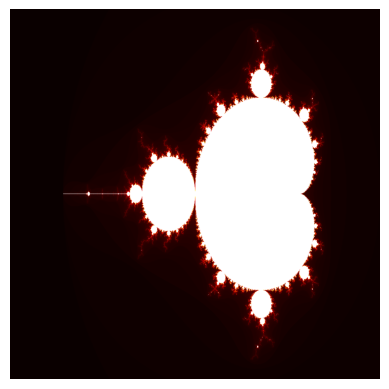

In [8]:
import time
import matplotlib.pyplot as plt
import pyopencl as cl
import numpy as np
from mandelbrot_gpu import KERNEL_SRC

ctx   = cl.create_some_context(interactive=False)
queue = cl.CommandQueue(ctx)
prog  = cl.Program(ctx, KERNEL_SRC).build()

N, MAX_ITER = 1024, 200
X_MIN, X_MAX = -2.5, 1.0
Y_MIN, Y_MAX = -1.25, 1.25

image = np.zeros((N, N), dtype=np.int32)
image_dev = cl.Buffer(ctx, cl.mem_flags.WRITE_ONLY, image.nbytes)

# --- Warm up (first launch triggers a kernel compile) ---
prog.mandelbrot(queue, (64, 64), None, image_dev,
                np.float32(X_MIN), np.float32(X_MAX),
                np.float32(Y_MIN), np.float32(Y_MAX),
                np.int32(64), np.int32(MAX_ITER))
queue.finish()

# --- Time the real run ---
t0 = time.perf_counter()
prog.mandelbrot(queue, (N, N), None, image_dev,
                np.float32(X_MIN), np.float32(X_MAX),
                np.float32(Y_MIN), np.float32(Y_MAX),
                np.int32(N), np.int32(MAX_ITER))
queue.finish()
elapsed = time.perf_counter() - t0

cl.enqueue_copy(queue, image, image_dev)
queue.finish()

print(f"GPU {N}x{N}: {elapsed*1e3:.1f} ms")
plt.imshow(image, cmap='hot', origin='lower'); plt.axis('off')
plt.savefig("mandelbrot_gpu.png", dpi=150, bbox_inches='tight')

I have now completed the `mandelbrot_tutorial.md`.

```python
# From slide 9

# Kernel signature -- fill in the body following the tutorial
KERNEL_SRC = """
__kernel void mandelbrot(
    __global int *result,
    const float x_min, const float x_max,
    const float y_min, const float y_max,
    const int N, const int max_iter)
{
    int col = get_global_id(0);
    int row = get_global_id(1);
    // ... your escape-time loop here ...
}"""

# Host launch -- note np.float32/np.int32 wrapping for every scalar
prog.mandelbrot(
    queue, (N, N), None, image_dev,
    np.float32(X_MIN), np.float32(X_MAX),
    np.float32(Y_MIN), np.float32(Y_MAX),
    np.int32(N), np.int32(MAX_ITER),
)
queue.finish()
```

- **The kernel is a direct translation of your Numba escape-time loop into OpenCL C**

Noted! Yes it is a direct translation.

- **Each work-item computes its own *c* from its pixel coordinates — no input array needed**

Indeed yes. This was fixed in OpenCL using the `tmp` variable.

- **Launch with 2D global size `(N, N)`; wrap every scalar as `np.float32(...)/np.int32(...)`**

Done. Please see the code above from step 7.

- **Visualise with `plt.imshow` and save the image**

Done. Please see the outputted image above from step 7.

****After it produces a correct image, time it:****

- **Add a warm-up call first (first launch triggers kernel JIT compile)**

Done in step 7 above.

- **Time with `time.perf_counter()`; call `queue.finish()` before stopping the clock**

Noted! Done! Please see the code above from step 7.

****Done?** Record GPU f32 runtime in performance notebook (MP3) → commit**

```sh
┌──(mikkel@pella)-[~/Sync/AAU/Semester 8/github/nsc-mikkel]
└─$ git log -n 1
commit aa3a638a6259121b11a00b227528f3c6f9868ddf (HEAD -> main)
Author: mikkel-coder <mikkel.ks.sorensen@gmail.com>
Date:   Wed Apr 22 11:06:13 2026 +0000

    l10: milestone 1 done
```

### ****Milestone 2:** Float32 vs Float64 (20 min)**

****Task:** Add a float64 version and compare speed and image quality.**

In [9]:
import pyopencl as cl
ctx   = cl.create_some_context(interactive=False)
# From slide 11

# 1. Check fp64 support
dev = ctx.devices[0]
if 'cl_khr_fp64' not in dev.extensions:
    print("No native fp64 -- Apple Silicon: emulated, expect large slowdown")

# 2. Add this pragma at the top of your f64 kernel string
#pragma OPENCL EXTENSION cl_khr_fp64 : enable

# 3. Three changes inside the kernel:
#    float  -> double
#    0.0f, 4.0f -> 0.0, 4.0     (drop the f suffix)
#     (float)N  -> (double)N

# 4. Wrap scalars as np.float64(...) in the host launch call

1. **Check that your device supports fp64 (see code example)**

No output from the code above. My device does support float64.

2. **Copy your M1 kernel; rename to `mandelbrot_f64`; change: `float` → `double`, literal suffixes `0.0f/4.0f → 0.0/4.0`; add the pragma line at the top**

In [10]:
KERNEL_SRC_F64 = """
#pragma OPENCL EXTENSION cl_khr_fp64 : enable

__kernel void mandelbrot_f64(
    __global int *result,
    const double x_min, const double x_max,
    const double y_min, const double y_max,
    const int N, const int max_iter)
{
    int col = get_global_id(0);
    int row = get_global_id(1);
    if (col >= N || row >= N) return;   // guard against over-launch

    double c_real = x_min + col * (x_max - x_min) / (double)N;
    double c_imag = y_min + row * (y_max - y_min) / (double)N;

    double zr = 0.0, zi = 0.0;
    int count = 0;
    while (count < max_iter && zr*zr + zi*zi <= 4.0) {
        double tmp = zr*zr - zi*zi + c_real;
        zi = 2.0 * zr * zi + c_imag;
        zr = tmp;
        count++;
    }
    result[row * N + col] = count;
}
"""

3. **Time both at $N=1024$ and $N=2048$ — what is the f32/f64 speed ratio?**

In [11]:
import numpy as np
from mandelbrot_gpu import KERNEL_SRC as KERNEL_SRC_F32

queue = cl.CommandQueue(ctx)
prog_f32 = cl.Program(ctx, KERNEL_SRC_F32).build()
prog_f64 = cl.Program(ctx, KERNEL_SRC_F64).build()

N, MAX_ITER = 1024, 200
X_MIN, X_MAX = -2.5, 1.0
Y_MIN, Y_MAX = -1.25, 1.25

image_1024_f32 = np.zeros((1024, 1024), dtype=np.int32)
image_dev_1024_f32 = cl.Buffer(ctx, cl.mem_flags.WRITE_ONLY, image_1024_f32.nbytes)
image_2048_f32 = np.zeros((2048, 2048), dtype=np.int32)
image_dev_2048_f32 = cl.Buffer(ctx, cl.mem_flags.WRITE_ONLY, image_2048_f32.nbytes)
image_1024_f64 = np.zeros((1024, 1024), dtype=np.int32)
image_dev_1024_f64 = cl.Buffer(ctx, cl.mem_flags.WRITE_ONLY, image_1024_f64.nbytes)
image_2048_f64 = np.zeros((2048, 2048), dtype=np.int32)
image_dev_2048_f64 = cl.Buffer(ctx, cl.mem_flags.WRITE_ONLY, image_2048_f64.nbytes)

# --- Warm up (first launch triggers a kernel compile) ---
dummy_buff_dev = cl.Buffer(ctx, cl.mem_flags.WRITE_ONLY, image_1024_f32.nbytes)
prog_f32.mandelbrot(
    queue, (64, 64), None, dummy_buff_dev,
    np.float32(X_MIN), np.float32(X_MAX),
    np.float32(Y_MIN), np.float32(Y_MAX),
    np.int32(64), np.int32(MAX_ITER)
)
queue.finish()

prog_f64.mandelbrot_f64(
    queue, (64, 64), None, dummy_buff_dev,
    np.float64(X_MIN), np.float64(X_MAX),
    np.float64(Y_MIN), np.float64(Y_MAX),
    np.int32(64), np.int32(MAX_ITER)
)
queue.finish()

/opt/conda/envs/nsc/lib/python3.11/site-packages/pyopencl/__init__.py:578: UserWarning: PyOpenCL compiler caching failed with an exception:
[begin exception]
Traceback (most recent call last):
  File "/opt/conda/envs/nsc/lib/python3.11/site-packages/pyopencl/cache.py", line 514, in create_built_program_from_source_cached
    _create_built_program_from_source_cached(
  File "/opt/conda/envs/nsc/lib/python3.11/site-packages/pyopencl/cache.py", line 424, in _create_built_program_from_source_cached
    src = src + b"\n\n__constant int pyopencl_defeat_cache_%s = 0;" % (
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: %b requires a bytes-like object, or an object that implements __bytes__, not 'str'
[end exception]
  lambda: create_built_program_from_source_cached(


In [12]:
import time

# --- Time the real run ---
# 1024 f32
t0 = time.perf_counter()
prog_f32.mandelbrot(
    queue, (1024, 1024), None, image_dev_1024_f32,
    np.float32(X_MIN), np.float32(X_MAX),
    np.float32(Y_MIN), np.float32(Y_MAX),
    np.int32(1024), np.int32(MAX_ITER)
)
queue.finish()
elapsed_1024_f32 = time.perf_counter() - t0
cl.enqueue_copy(queue, image_1024_f32, image_dev_1024_f32)
queue.finish()
print(f"{elapsed_1024_f32=}")

# # 1024 f64
t0 = time.perf_counter()
prog_f64.mandelbrot_f64(
    queue, (1024, 1024), None, image_dev_1024_f64,
    np.float64(X_MIN), np.float64(X_MAX),
    np.float64(Y_MIN), np.float64(Y_MAX),
    np.int32(1024), np.int32(MAX_ITER)
)
queue.finish()
elapsed_1024_f64 = time.perf_counter() - t0
cl.enqueue_copy(queue, image_1024_f64, image_dev_1024_f64)
queue.finish()
print(f"{elapsed_1024_f64=}")

# # 2048 f32
t0 = time.perf_counter()
prog_f32.mandelbrot(
    queue, (2048, 2048), None, image_dev_2048_f32,
    np.float32(X_MIN), np.float32(X_MAX),
    np.float32(Y_MIN), np.float32(Y_MAX),
    np.int32(2048), np.int32(MAX_ITER)
)
queue.finish()
elapsed_2048_f32 = time.perf_counter() - t0
cl.enqueue_copy(queue, image_2048_f32, image_dev_2048_f32)
queue.finish()
print(f"{elapsed_2048_f32=}")

# 2048 f64
t0 = time.perf_counter()
prog_f64.mandelbrot_f64(
    queue, (2048, 2048), None, image_dev_2048_f64,
    np.float64(X_MIN), np.float64(X_MAX),
    np.float64(Y_MIN), np.float64(Y_MAX),
    np.int32(2048), np.int32(MAX_ITER)
)
queue.finish()
elapsed_2048_f64 = time.perf_counter() - t0
cl.enqueue_copy(queue, image_2048_f64, image_dev_2048_f64)
queue.finish()
print(f"{elapsed_2048_f64=}")

elapsed_1024_f32=0.0015235589999065269
elapsed_1024_f64=0.007998920999852999
elapsed_2048_f32=0.002838465999957407
elapsed_2048_f64=0.01747659700049553


/tmp/ipykernel_22939/492714710.py:6: RepeatedKernelRetrieval: Kernel 'mandelbrot' has been retrieved more than once. Each retrieval creates a new, independent kernel, at possibly considerable expense. To avoid the expense, reuse the retrieved kernel instance. To avoid this warning, use cl.Kernel(prg, name).
  prog_f32.mandelbrot(
/tmp/ipykernel_22939/492714710.py:20: RepeatedKernelRetrieval: Kernel 'mandelbrot_f64' has been retrieved more than once. Each retrieval creates a new, independent kernel, at possibly considerable expense. To avoid the expense, reuse the retrieved kernel instance. To avoid this warning, use cl.Kernel(prg, name).
  prog_f64.mandelbrot_f64(


In [13]:
speedup_ration_1024 = elapsed_1024_f32 / elapsed_1024_f64
speedup_ration_2048 = elapsed_2048_f32 / elapsed_2048_f64

print(f"Speedup ration (1024): {speedup_ration_1024:.2f}x")
print(f"Speedup ration (2048): {speedup_ration_2048:.2f}x")

Speedup ration (1024): 0.19x
Speedup ration (2048): 0.16x


- **Is the measured speed ratio consistent with your Roofline prediction?**

Lets see if my mandelbort beats my ridge point.

In [14]:
!clpeak --platform 0 --device 0


Platform: AMD Accelerated Parallel Processing
  Device: gfx1035
    Driver version  : 3581.0 (HSA1.1,LC) (Linux x64)
    Compute units   : 6
    Clock frequency : 2200 MHz

    Global memory bandwidth (GBPS)
      float   : 76.67
      float2  : 83.27
      float4  : 83.38
      float8  : 84.04
      float16 : 86.92

    Single-precision compute (GFLOPS)
      float   : 1616.53
      float2  : 2729.83
      float4  : 2788.07
      float8  : 2704.68
      float16 : 2636.96

    Half-precision compute (GFLOPS)
      half   : 2774.83
      half2  : 5291.98
      half4  : 5218.88
      half8  : 5192.87
      half16 : 4988.41

    Double-precision compute (GFLOPS)
      double   : 198.50
      double2  : 196.64
      double4  : 196.22
      double8  : 189.17
      double16 : 189.80

    Integer compute (GIOPS)
      int   : 513.19
      int2  : 491.79
      int4  : 439.49
      int8  : 510.53
      int16 : 509.49

    Integer compute Fast 24bit (GIOPS)
      int   : 2096.29
      int2  : 1

$$\text{Bandwidth} = 80 \space \text{GB/s}$$

**Rigde point for f32**

$$\text{Peak FLOPS}_{\text{f32}} = 2,700 \space \text{GFLOPS}$$

$$\text{Ridge Point}_{\text{f32}} = \frac{2,700 \space \text{GFLOPS}}{80 \space \text{GB/s}} = 33,75 \space {\text{FLOPs/byte}}$$

**Rigde point for f64**

$$\text{Peak FLOPS}_{\text{f64}} = 197 \space \text{GFLOPS}$$

$$\text{Ridge Point}_{\text{f64}} = \frac{197 \space \text{GFLOPS}}{80 \space \text{GB/s}} = 2,46 \space {\text{FLOPs/byte}}$$

**Mandelbrot 1024**

$$ \text{Algorithmic Intensity} = \frac{\text{Number of FLOPs}}{\text{Bytes transferred from memory}} $$

```c
__kernel void mandelbrot(
    __global int *result,
    const float x_min, const float x_max,
    const float y_min, const float y_max,
    const int N, const int max_iter)
{
    int col = get_global_id(0);
    int row = get_global_id(1);
    if (col >= N || row >= N) return;

    float c_real = x_min + col * (x_max - x_min) / (float)N;
    float c_imag = y_min + row * (y_max - y_min) / (float)N;

    float zr = 0.0f, zi = 0.0f;
    int count = 0;
    while (count < max_iter && zr*zr + zi*zi <= 4.0f) {      // 3 FLOPs
        float tmp = zr*zr - zi*zi + c_real;                  // 4 FLOPs
        zi = 2.0f * zr * zi + c_imag;                        // 3 FLOPs
        zr = tmp;
        count++;
    }
    result[row * N + col] = count;                           // Write 4 Bytes (int32)
}
```

$$\text{FLOPs per pixel} = 10 \space \text{FLOPs}$$

Lets compute the mean FLOPs computed, since the while loop iterations differ per pixel. The image is the iterations counts.

In [15]:
print(f"{np.mean(image_1024_f32)=:.4f}")
print(f"{np.mean(image_1024_f64)=:.4f}")
print(f"{np.mean(image_2048_f32)=:.4f}")
print(f"{np.mean(image_2048_f64)=:.4f}")

np.mean(image_1024_f32)=38.9546
np.mean(image_1024_f64)=38.9564
np.mean(image_2048_f32)=38.9472
np.mean(image_2048_f64)=38.9478


The difference is so small. Lets assume:

$$\text{Number of FLOPs per pixel} = 10 \space \text{FLOPs} \times 38.95 = 389.5 \space \text{FLOPs}$$

The for the full $1024$ image it is:

$$\text{Number of FLOPs} = 389.5 \space \text{FLOPs} \times 1024^2 = 408,420,352 \space \text{FLOPs} $$

Now the bytes bandwidth

$$ \text{Bytes transferred from memory}_{1024} = 1024^2 \times 4 \space \text{Bytes} = 4,194,304 \space \text{Bytes}$$

Then the Algorithmic Intensity

$$ \text{AI}_{1024} = \frac{408,420,352 \space \text{FLOPs}}{4,194,304 \space \text{Bytes}} = 97.38 \space \text{FLOPs/Byte}$$

**Mandelbrot 2048**

The only difference is the number of bandwidth bytes

$$ \text{Bytes transferred from memory}_{2048} = 2048^2 \times 4 \space \text{Bytes} = 16,777,216 \space \text{Bytes}$$

$$ \text{AI}_{2048} = \frac{408,420,352 \space \text{FLOPs}}{16,777,216 \space \text{Bytes}} = 24.34 \space \text{FLOPs/Byte}$$

Lets plot this.

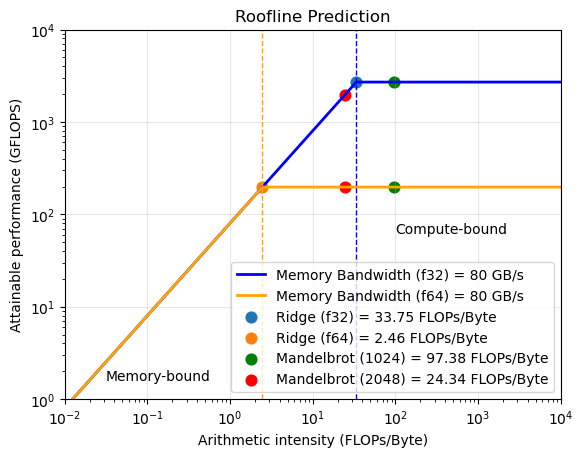

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# hardware limits
f32_peak = 2700 # GFLOPS
f64_peak = 197 # GFLOPS
memory_bandwidth = 80 # GBPS

ridge_f32 = 33.75 
ridge_f64 = 2.46
x_ridge_point_f32 = f32_peak / memory_bandwidth
x_ridge_point_f64 = f64_peak / memory_bandwidth

# Algorithmic Intensity
ai_1024 = 97.38 # FLOPs/Byte
ai_2048 = 24.34 # # FLOPs/Byte
y_ai_1024_f32 = min(memory_bandwidth * ai_1024, f32_peak)
y_ai_2048_f32 = min(memory_bandwidth * ai_2048, f32_peak)
y_ai_1024_f64 = min(memory_bandwidth * ai_1024, f64_peak)
y_ai_2048_f64 = min(memory_bandwidth * ai_2048, f64_peak)


# same axes as jimmy - plot samples
x = np.logspace(-2, 4, 200)

memory_bandwidth_limit_f32 = np.minimum(memory_bandwidth * x, f32_peak)
memory_bandwidth_limit_f64 = np.minimum(memory_bandwidth * x, f64_peak)


# float32
plt.plot(x, memory_bandwidth_limit_f32, label=f"Memory Bandwidth (f32) = {memory_bandwidth} GB/s", linewidth="2", color="blue")
plt.plot(x, memory_bandwidth_limit_f64, label=f"Memory Bandwidth (f64) = {memory_bandwidth} GB/s", linewidth="2", color="orange")
plt.scatter(x_ridge_point_f32, f32_peak, label=f"Ridge (f32) = {ridge_f32} FLOPs/Byte", s=60)
plt.scatter(x_ridge_point_f64, f64_peak, label=f"Ridge (f64) = {ridge_f64} FLOPs/Byte", s=60)
plt.scatter(ai_1024, y_ai_1024_f32, label=f"Mandelbrot (1024) = {ai_1024} FLOPs/Byte", color="green", s=60)
plt.scatter(ai_2048, y_ai_2048_f32, label=f"Mandelbrot (2048) = {ai_2048} FLOPs/Byte", color="red", s=60)
plt.scatter(ai_1024, y_ai_1024_f64, color="green", s=60)
plt.scatter(ai_2048, y_ai_2048_f64, color="red", s=60)
plt.axvline(x_ridge_point_f32, linestyle="dashed", linewidth="1", color="blue")
plt.axvline(x_ridge_point_f64, linestyle="dashed", linewidth="1", color="orange")
plt.text(10**-1.5, 10**0.2, "Memory-bound")
plt.text(10**2, 10**1.8, "Compute-bound")
plt.xlabel("Arithmetic intensity (FLOPs/Byte)")
plt.ylabel("Attainable performance (GFLOPS)")
plt.xscale("log")
plt.yscale("log")
plt.xlim(10**-2, 10**4)
plt.ylim(10**0, 10**4)
plt.grid(alpha=0.3)
plt.legend()
plt.title("Roofline Prediction")
plt.show()


*float32:* From the plot above (the blue line), we can see that mandelbrot for the smaller image is compute bound but the smaller image is memory bounded. Both at very close at the ridge point. It seems that my cl device (GPU) was made for workloads like mandelbrot float32.

*float64:* From the plot above (the orange line) shows that both mandelbrot images are compute bounded, which is to be expected due to float64 requiring more compute per byte than float32 version.

- **Apple Silicon (M-series): fp64 is emulated in software — expect a very large slowdown**

I do not have any M-series computer.

****Done?** Record f32 and f64 runtimes in performance notebook (MP3) → commit**

```sh
┌──(mikkel@pella)-[~/Sync/AAU/Semester 8/github/nsc-mikkel]
└─$ git log -n 1
commit 99f8ffec365b88a4fda3c785dbb22773e0b36e01 (HEAD -> main)
Author: mikkel-coder <mikkel.ks.sorensen@gmail.com>
Date:   Fri Apr 24 08:10:48 2026 +0000

    l10: milestone 2 done
```

### ****Milestone 3:** Benchmark GPU**

****Task:** Time your GPU kernels at the same grid sizes you used in MP1 and MP2. Reuse the CPU runtimes already in your performance notebook — no need to re-run them.**

1. **Time `mandelbrot_gpu_f32` and `mandelbrot_gpu_f64` at your benchmark *N* values**

In [17]:
import pyopencl as cl
import numpy as np

# From slide 13, adapted by me

import statistics, time, matplotlib.pyplot as plt
def timed(fn, *args, runs=3):
    """Benchmark the median runtime of a function.
    
    Parameters
    ----------
    fn : callable
        The function to benchmark.
    *args
        Arguments parsed to the benchmarked function.
    runs : int, optional
        Number of runs.

    Returns
    -------
    float
        The median runtime.    
    """
    return statistics.median([fn(*args) for _ in range(runs)])

In [18]:
from mandelbrot_gpu import KERNEL_SRC as KERNEL_SRC_F32

def run_mandelbrot_f32(N):
    """Compute the normal viewed mandelbrot set on default OpenCL device using f32.

    Parameters
    ----------
    N : int
        The pixel width and height.
    
    Returns
    -------
    float
        The runtime excluding compilation.
    """
    ctx   = cl.create_some_context(interactive=False)
    queue = cl.CommandQueue(ctx)
    prog  = cl.Program(ctx, KERNEL_SRC_F32).build()

    # Same parameters used in mp2
    MAX_ITER = 100
    X_MIN, X_MAX = -2.0, 1.0
    Y_MIN, Y_MAX = -1.5, 1.5

    image = np.zeros((N, N), dtype=np.int32)
    image_dev = cl.Buffer(ctx, cl.mem_flags.WRITE_ONLY, image.nbytes)

    # --- Warm up (first launch triggers a kernel compile) ---
    prog.mandelbrot(queue, (64, 64), None, image_dev,
                    np.float32(X_MIN), np.float32(X_MAX),
                    np.float32(Y_MIN), np.float32(Y_MAX),
                    np.int32(64), np.int32(MAX_ITER))
    queue.finish()

    # --- Time the real run ---
    t0 = time.perf_counter()
    prog.mandelbrot(queue, (N, N), None, image_dev,
                    np.float32(X_MIN), np.float32(X_MAX),
                    np.float32(Y_MIN), np.float32(Y_MAX),
                    np.int32(N), np.int32(MAX_ITER))
    queue.finish()
    return time.perf_counter() - t0

def run_mandelbrot_f64(N):
    """Compute the normal viewed mandelbrot set on default OpenCL device using f64.

    Parameters
    ----------
    N : int
        The pixel width and height.
    
    Returns
    -------
    float
        The runtime excluding compilation.
    """
    ctx   = cl.create_some_context(interactive=False)
    queue = cl.CommandQueue(ctx)
    prog  = cl.Program(ctx, KERNEL_SRC_F64).build()

    # Same parameters used in mp2
    MAX_ITER = 100
    X_MIN, X_MAX = -2.0, 1.0
    Y_MIN, Y_MAX = -1.5, 1.5

    image = np.zeros((N, N), dtype=np.int32)
    image_dev = cl.Buffer(ctx, cl.mem_flags.WRITE_ONLY, image.nbytes)

    # --- Warm up (first launch triggers a kernel compile) ---
    prog.mandelbrot_f64(queue, (64, 64), None, image_dev,
                    np.float64(X_MIN), np.float64(X_MAX),
                    np.float64(Y_MIN), np.float64(Y_MAX),
                    np.int32(64), np.int32(MAX_ITER))
    queue.finish()

    # --- Time the real run ---
    t0 = time.perf_counter()
    prog.mandelbrot_f64(queue, (N, N), None, image_dev,
                    np.float64(X_MIN), np.float64(X_MAX),
                    np.float64(Y_MIN), np.float64(Y_MAX),
                    np.int32(N), np.int32(MAX_ITER))
    queue.finish()
    return time.perf_counter() - t0

2. **Combine GPU runtimes with your recorded MP1/MP2 numbers**

In [19]:
# From slide 13, filled in with my used values
N = 4096                        # match your MP1/MP2 benchmark N
results = {
    "GPU f32": timed(lambda: run_mandelbrot_f32(N)),
    "GPU f64": timed(lambda: run_mandelbrot_f64(N)),
    # Paste your MP1/MP2 runtimes here:
    "Naive": 67.556, 
    "NumPy": 11.321, 
    "Numba": 0.751,
    "Multiprocessing": 0.359,
    "Dask Local": 0.738,
    "Dask Cluster": 0.540
}

print(f"GPU (f32): {results['GPU f32']:.3f}s")
print(f"GPU (f64): {results['GPU f64']:.3f}s")

/opt/conda/envs/nsc/lib/python3.11/site-packages/pyopencl/__init__.py:578: UserWarning: PyOpenCL compiler caching failed with an exception:
[begin exception]
Traceback (most recent call last):
  File "/opt/conda/envs/nsc/lib/python3.11/site-packages/pyopencl/cache.py", line 514, in create_built_program_from_source_cached
    _create_built_program_from_source_cached(
  File "/opt/conda/envs/nsc/lib/python3.11/site-packages/pyopencl/cache.py", line 424, in _create_built_program_from_source_cached
    src = src + b"\n\n__constant int pyopencl_defeat_cache_%s = 0;" % (
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: %b requires a bytes-like object, or an object that implements __bytes__, not 'str'
[end exception]
  lambda: create_built_program_from_source_cached(
/tmp/ipykernel_614/390168630.py:25: RepeatedKernelRetrieval: Kernel 'mandelbrot' has been retrieved more than once. Each retrieval creates a new, independent kernel, at possibly considerable expe

GPU (f32): 0.006s
GPU (f64): 0.033s


3. **Plot as a bar chart with a log-scale y -axis — this is the MP3 performance comparison figure**

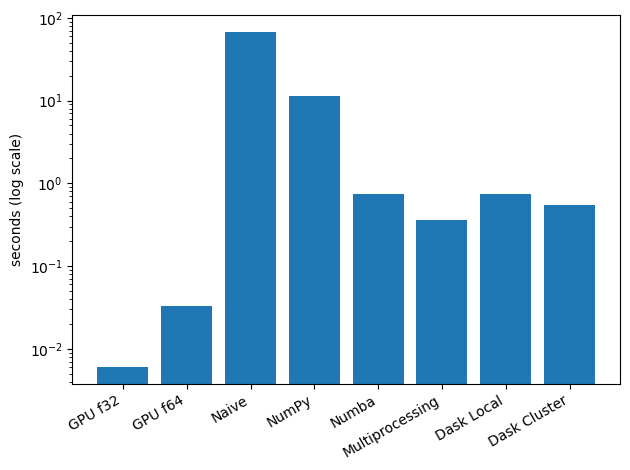

In [20]:
names, times = zip(*results.items())
plt.bar(names, times, log=True)
plt.ylabel("seconds (log scale)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("benchmark_mp3.png", dpi=150)

- **Include: naive Python, NumPy, Numba f32/f64, multiprocessing, Dask local, Dask cluster, GPU f32, GPU f64**

I am only missing the Numba for f32 and f64 at 4096.

In [21]:
from numba import njit


# From lecture 3

@njit
def mandelbrot_point_numba(c, max_iter=100):
    z = 0j
    for n in range(max_iter):
        if z.real*z.real+z.imag*z.imag > 4.0:
            return n
        z = z*z + c
    return max_iter

@njit
def mandelbrot_numba_typed(xmin, xmax, ymin, ymax,
                            width, height, max_iter=100, dtype=np.float64):
    x = np.linspace(xmin, xmax, width).astype(dtype)
    y = np.linspace(ymin, ymax, height).astype(dtype)
    result = np.zeros((height, width), dtype=np.int32)
    for i in range(height):
        for j in range(width):
            c = x[j] + 1j * y[i]
            result[i, j] = mandelbrot_point_numba(c, max_iter)
    return result

In [22]:
from timeit import timeit

# warmup
mandelbrot_numba_typed(-2, 1, -1.5, 1.5, 4096, 4096, dtype=np.float32)
mandelbrot_numba_typed(-2, 1, -1.5, 1.5, 4096, 4096, dtype=np.float64)

results_plus_numba = {
    **results,
    "Numba f32": timeit(lambda: mandelbrot_numba_typed(-2, 1, -1.5, 1.5, 4096, 4096, dtype=np.float32), number=3)/3,
    "Numba f64": timeit(lambda: mandelbrot_numba_typed(-2, 1, -1.5, 1.5, 4096, 4096, dtype=np.float64), number=3)/3,
}

del results_plus_numba["Numba"]

- **Where does GPU sit relative to Numba? To naive Python? (Recall the L01 starting point.)**

Numba f32 0.731 s
Numba f64 0.707 s


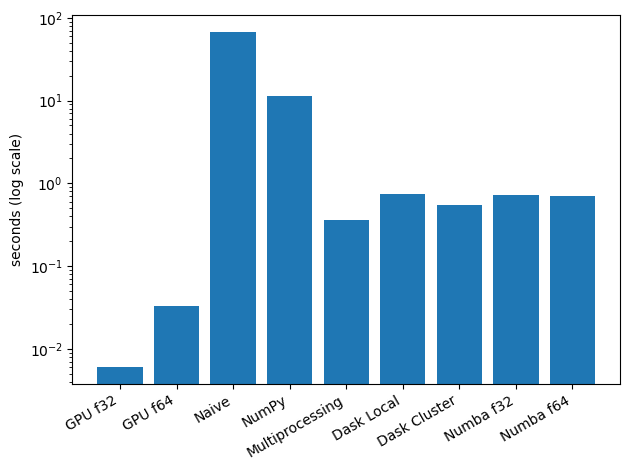

In [23]:
print(f"Numba f32 {results_plus_numba['Numba f32']:.3f} s")
print(f"Numba f64 {results_plus_numba['Numba f64']:.3f} s")

names, times = zip(*results_plus_numba.items())
plt.bar(names, times, log=True)
plt.ylabel("seconds (log scale)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("benchmark_mp3.png", dpi=150)

In [24]:
gpu_numba_relative = results_plus_numba["Numba f32"] / results_plus_numba["GPU f32"]
gpu_naive_relative = results_plus_numba["Naive"] / results_plus_numba["GPU f32"]

print(f"GPU is {gpu_numba_relative:.2f}x times faster compared to Numba")
print(f"GPU is {gpu_naive_relative:.2f}x times faster compared to Naive Python")

GPU is 121.13x times faster compared to Numba
GPU is 11189.24x times faster compared to Naive Python


****Done?** Combined benchmark chart in performance notebook (MP3) → commit**

The benchmark chart is combined above.

```sh
┌──(mikkel@pella)-[~/Sync/AAU/Semester 8/github/nsc-mikkel]
└─$ git log -n 1
commit a5f110eefef83e3c00a712f61864cc6b6c4b940e (HEAD -> main)
Author: mikkel-coder <mikkel.ks.sorensen@gmail.com>
Date:   Fri Apr 24 11:30:21 2026 +0000

    l10: milestone 3 done
```

## Reflection

This mini project allowed me to test my numerical accuracy, conduct testing via pytest including documenting every implementation across all of my different milestone's files, together with OpenCL programming on my GPU. The GPU offered a *massive* performance speedup compared to my initial Naïve Python implementation of more than $11,000\times$. This shows that the GPU is *the* hardware to choose for massive parallel compute, such as image processing, matrix calculations, and the Mandelbrot set. It would not be worth the effort if the problem is small in data and/or if the problem is not massively parallel (task dependencies), for example due to PCI transfer times. Using `pytest`, I was able to shown that the given implementations, not just ran, but were also correct, all returning the same Mandelbrot image. One minor issue was how the complex grid was calculated, but I was able to quickly resolve it. This shows that testing and documentation are very important. Regarding specifically docstrings, I would say, for my use case, they were not worthwhile since the implementations were so similar.

#### **MP1**

| Implementation | Resolution | Workers/Cores | Time    | Speedup    |
| -------------- | ---------- | ------------- | ------- | ---------- |
| Naive          | 512x512    | 1             | 1.457s  | *baseline* |
| NumPy          | 512x512    | 1             | 0.330s  | 4.42x      |
| Numba          | 512x512    | 1             | 0.025s  | 58.28x     |
| Numba Parallel | 512x512    | 16 (Threads)  | 0.003s  | 485.67x    |


| Implementation | Resolution | Workers/Cores | Time    | Speedup    |
| -------------- | ---------- | ------------- | ------- | ---------- |
| Naive          | 1024x1024  | 1             | 4.787s  | *baseline* |
| NumPy          | 1024x1024  | 1             | 0.903s  | 5.30x      |
| Numba          | 1024x1024  | 1             | 0.075s  | 63.83x     |
| Numba Parallel | 1024x1024  | 16 (Threads)  | 0.011s  | 435.18x    |


| Implementation | Resolution | Workers/Cores | Time    | Speedup    |
| -------------- | ---------- | ------------- | ------- | ---------- |
| Naive          | 4096x4096  | 1             | 68.363s | *baseline* |
| NumPy          | 4096x4096  | 1             | 12.725s | 5.37x      |
| Numba          | 4096x4096  | 1             | 1.079s  | 64.36x     |
| Numba Parallel | 4096x4096  | 16 (Threads)  | 0.177s  | 386.23x    |


#### **MP2**

| Implementation   | Resolution | Workers/Cores | Time    | Speedup    |
| ---------------- | ---------- | ------------- | ------- | ---------- |
| Multiprocessing  | 1024x1024  | 1             | 0.055s  | *baseline* |
| Multiprocessing  | 1024x1024  | 2             | 0.029s  | 1.90x      |
| Multiprocessing  | 1024x1024  | 3             | 0.036s  | 1.53x      |
| Multiprocessing  | 1024x1024  | 4             | 0.026s  | 2.12x      |
| Multiprocessing  | 1024x1024  | 5             | 0.026s  | 2.12x      |
| Multiprocessing  | 1024x1024  | 6             | 0.020s  | 2.75x      |
| Multiprocessing  | 1024x1024  | 7             | 0.020s  | 2.75x      |
| Multiprocessing  | 1024x1024  | 8             | 0.017s  | 3.24x      |
| Multiprocessing  | 1024x1024  | 9             | 0.017s  | 3.24x      |
| Multiprocessing  | 1024x1024  | 10            | 0.015s  | 3.67x      |
| Multiprocessing  | 1024x1024  | 11            | 0.014s  | 3.93x      |
| Multiprocessing  | 1024x1024  | 12            | 0.013s  | 4.23x      |
| Multiprocessing  | 1024x1024  | 13            | 0.012s  | 4.58x      |
| Multiprocessing  | 1024x1024  | 14            | 0.012s  | 4.58x      |
| Multiprocessing  | 1024x1024  | 15            | 0.011s  | 5.00x      |
| Multiprocessing  | 1024x1024  | 16            | 0.011s  | 5.00x      |

| Implementation   | Resolution | Workers/Cores | Time    | Speedup vs Numba Serial |
| ---------------- | ---------- | ------------- | ------- | ----------------------- |
| Dask Local       | 4096x4096  | 8             | 0.266s  | 2.70x                   |
| Dask Local       | 2048x2048  | 8             | 0.088s  | 8.13x                   |
| Dask Local       | 1024x1024  | 8             | 0.059s  | 12.10x                  |
| Dask Local       | 512x512    | 8             | 0.052s  | 13.70x                  |

| Implementation   | Resolution | Workers/Cores | Time    | Speedup    |
| ---------------- | ---------- | ------------- | ------- | ---------- |
| Dask Cluster     | 4096x4096  | 1             | 1.011s  | *baseline* |
| Dask Cluster     | 4096x4096  | 2             | 0.646s  | 1.57x      |
| Dask Cluster     | 4096x4096  | 3             | 0.540s  | 1.87x      |

#### **MP3**
| Implementation   | Resolution | Runtime (s) | speedup vs Numba f32 |
| ---------------- | ---------- | ----------- | -------------------- |
| GPU f32          | 1024x1024  | 0.002       | 365.50x              |
| GPU f64          | 1024x1024  | 0.008       | 91.38x               |
| GPU f32          | 2048x2048  | 0.003       | 243.67x              |
| GPU f64          | 2048x2048  | 0.017       | 43x                  |
| GPU f32          | 4096x4096  | 0.006       | 121.83x              |
| GPU f64          | 4096x4096  | 0.033       | 22.15x               |
| Numba f32        | 4096x4096  | 0.731       | *baseline*           |
| Numba f64        | 4096x4096  | 0.707       | 1.03x                | 

| Implementation   | Resolution | Runtime (s) |
| ---------------- | ---------- | ----------- |
| Numba f32        | 1024x1024  | 0.046       |
| Numba f64        | 1024x1024  | 0.075       |
| Numba f32        | 2048x2048  | 0.184       |
| Numba f64        | 2048x2048  | 0.176       |


*Fair comparisons*

| Implementation   | Resolution | Runtime (s) | speedup vs Numba f32 |
| ---------------- | ---------- | ----------- | -------------------- |
| Numba f32        | 1024x1024  | 0.046       | *baseline*           |
| GPU f32          | 1024x1024  | 0.002       | 23x              |

| Implementation   | Resolution | Runtime (s) | speedup vs Numba f32 |
| ---------------- | ---------- | ----------- | -------------------- |
| Numba f32        | 2048x2048  | 0.184       | *baseline*           |
| GPU f32          | 2048x2048  | 0.003       | 63.33x               |

| Implementation   | Resolution | Runtime (s) | speedup vs Numba f32 |
| ---------------- | ---------- | ----------- | -------------------- |
| Numba f32        | 4096x4096  | 0.731       | *baseline*           |
| GPU f32          | 4096x4096  | 0.006       | 121.83x              |

| Implementation   | Resolution | Runtime (s) | speedup vs Numba f32 |
| ---------------- | ---------- | ----------- | -------------------- |
| Numba f64        | 1024x1024  | 0.075       | *baseline*           |
| GPU f64          | 1024x1024  | 0.008       | 9.38x                |

| Implementation   | Resolution | Runtime (s) | speedup vs Numba f32 |
| ---------------- | ---------- | ----------- | -------------------- |
| Numba f64        | 2048x2048  | 0.176       | *baseline*           |
| GPU f64          | 2048x2048  | 0.017       | 10.35x               |

| Implementation   | Resolution | Runtime (s) | speedup vs Numba f32 |
| ---------------- | ---------- | ----------- | -------------------- |
| Numba f64        | 4096x4096  | 0.707       | *baseline*           |
| GPU f64          | 4096x4096  | 0.033       | 21.43x               |

#### **Overall**

Using 4096x4096, 8 CPU cores, 6 CU (CPU) [OpenCL], and f32 precision.

| Implementation   | Time    | Speedup    |
| ---------------- | ------- | ---------- |
| Naive Python     | 67.556s | *baseline* | 
| Numpy Vectorized | 11.321s | 5.97x      |
| Numba JIT        | 0.751s  | 89.93x     |
| Multiprocessing  | 0.359s  | 188.17x    |
| Dask Local       | 0.738s  | 91.57x     |
| Dask Cluster     | 0.540s  | 125.13x    |
| GPU              | 0.006s  | 11,259.33x  |
